In [1]:
!pip install lightning torch torchvision torchaudio

   ---------------------------------------- 0.0/848.6 kB ? eta -:--:--
   ------------------------------------- -- 786.4/848.6 kB 4.2 MB/s eta 0:00:01
   ---------------------------------------- 848.6/848.6 kB 3.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/983.4 kB ? eta -:--:--
   ---------------------------------------- 983.4/983.4 kB 5.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/852.4 kB ? eta -:--:--
   ---------------------------------------- 852.4/852.4 kB 5.4 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import lightning as L

from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../Data/time_series_ready.csv")

df.head()

,InvoiceDate,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country,Year,Month,...,AverageSpend,LifetimeSales,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,2009-12-01 07:45:00,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,13085.0,United Kingdom,2009,12,...,28.4544,2134.08,13085.0,158,8,2134.08,3,4,5,345
1,2009-12-01 07:45:00,489434,79323P,PINK CHERRY LIGHTS,12,6.75,13085.0,United Kingdom,2009,12,...,28.4544,2134.08,13085.0,158,8,2134.08,3,4,5,345
2,2009-12-01 07:45:00,489434,79323W,WHITE CHERRY LIGHTS,12,6.75,13085.0,United Kingdom,2009,12,...,28.4544,2134.08,13085.0,158,8,2134.08,3,4,5,345
3,2009-12-01 07:45:00,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.25,13085.0,United Kingdom,2009,12,...,28.4544,2134.08,13085.0,158,8,2134.08,3,4,5,345
4,2009-12-01 07:45:00,489434,22064,PINK DOUGHNUT TRINKET POT,24,1.65,13085.0,United Kingdom,2009,12,...,28.4544,2134.08,13085.0,158,8,2134.08,3,4,5,345


In [4]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [5]:
sales = (
    df.groupby("InvoiceDate")["TotalSales"]
      .sum()
      .reset_index()
)

sales.head()

,InvoiceDate,TotalSales
0,2009-12-01 07:45:00,404.50
1,2009-12-01 07:46:00,145.80
2,2009-12-01 09:06:00,613.33
3,2009-12-01 09:08:00,282.90
4,2009-12-01 09:28:00,356.40


In [6]:
scaler = MinMaxScaler()

scaled_sales = scaler.fit_transform(
    sales["TotalSales"].values.reshape(-1,1)
)

In [7]:
sequence_length = 30

X = []
y = []

for i in range(len(scaled_sales)-sequence_length):

    X.append(
        scaled_sales[i:i+sequence_length]
    )

    y.append(
        scaled_sales[i+sequence_length]
    )

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(31406, 30, 1)
(31406, 1)


In [8]:
X = torch.tensor(
    X,
    dtype=torch.float32
)

y = torch.tensor(
    y,
    dtype=torch.float32
)

In [9]:
dataset = TensorDataset(X,y)

train_loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

In [10]:
class SalesLSTM(L.LightningModule):

    def __init__(self):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=64,
            num_layers=2,
            batch_first=True
        )

        self.fc = nn.Linear(
            64,
            1
        )

        self.loss_fn = nn.MSELoss()

    def forward(self,x):

        output,_ = self.lstm(x)

        output = output[:,-1,:]

        return self.fc(output)

    def training_step(self,batch,batch_idx):

        x,y = batch

        prediction = self(x)

        loss = self.loss_fn(
            prediction,
            y
        )

        self.log(
            "train_loss",
            loss
        )

        return loss

    def configure_optimizers(self):

        return torch.optim.Adam(
            self.parameters(),
            lr=0.001
        )

In [12]:
model = SalesLSTM()

trainer = L.Trainer(

    max_epochs=20,

    accelerator="auto",

    devices=1

)

trainer.fit(
    model,
    train_loader
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ lstm    │ LSTM    │ 50.4 K │ train │     0 │
│ 1 │ fc      │ Linear  │     65 │ train │     0 │
│ 2 │ loss_fn │ MSELoss │      0 │ train │     0 │
└───┴─────────┴─────────┴────────┴───────┴───────┘

Trainable params: 50.5 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 50.5 K                                                                                               
Total estimated model params size (MB): 0.202                                                                      
Modules in train mode: 3                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=20` reached.


In [13]:
model.eval()

with torch.no_grad():

    prediction = model(X)

prediction = prediction.numpy()

In [14]:
prediction = scaler.inverse_transform(
    prediction
)

actual = scaler.inverse_transform(
    y.numpy()
)

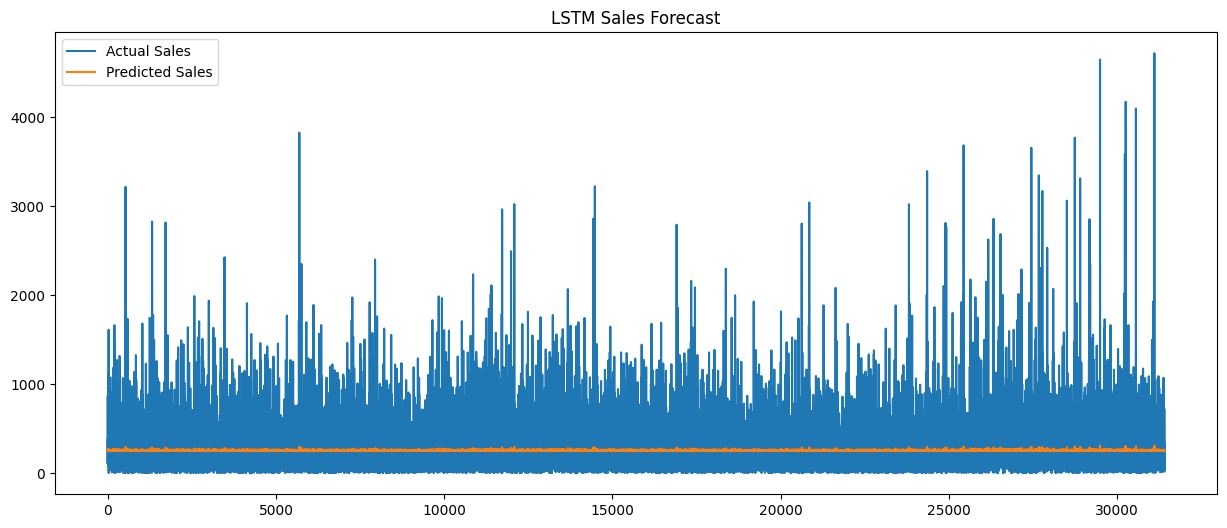

In [15]:
plt.figure(figsize=(15,6))

plt.plot(
    actual,
    label="Actual Sales"
)

plt.plot(
    prediction,
    label="Predicted Sales"
)

plt.legend()

plt.title("LSTM Sales Forecast")

plt.show()

In [16]:
last_sequence = scaled_sales[-30:]

future_predictions = []

current_sequence = last_sequence.copy()

for i in range(7):

    input_tensor = torch.tensor(
        current_sequence.reshape(1,30,1),
        dtype=torch.float32
    )

    with torch.no_grad():

        pred = model(input_tensor)

    pred_value = pred.item()

    future_predictions.append(pred_value)

    current_sequence = np.append(
        current_sequence[1:],
        [[pred_value]],
        axis=0
    )

In [17]:
future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1,1)
)

future_predictions

array([[255.02590558],
       [255.2838783 ],
       [255.42888901],
       [255.53840341],
       [255.61727629],
       [255.67124195],
       [255.70742426]])

In [18]:
last_sequence = scaled_sales[-30:]

future30 = []

current = last_sequence.copy()

for i in range(30):

    input_tensor = torch.tensor(
        current.reshape(1,30,1),
        dtype=torch.float32
    )

    with torch.no_grad():

        pred = model(input_tensor)

    value = pred.item()

    future30.append(value)

    current = np.append(
        current[1:],
        [[value]],
        axis=0
    )

In [19]:
future30 = scaler.inverse_transform(
    np.array(future30).reshape(-1,1)
)

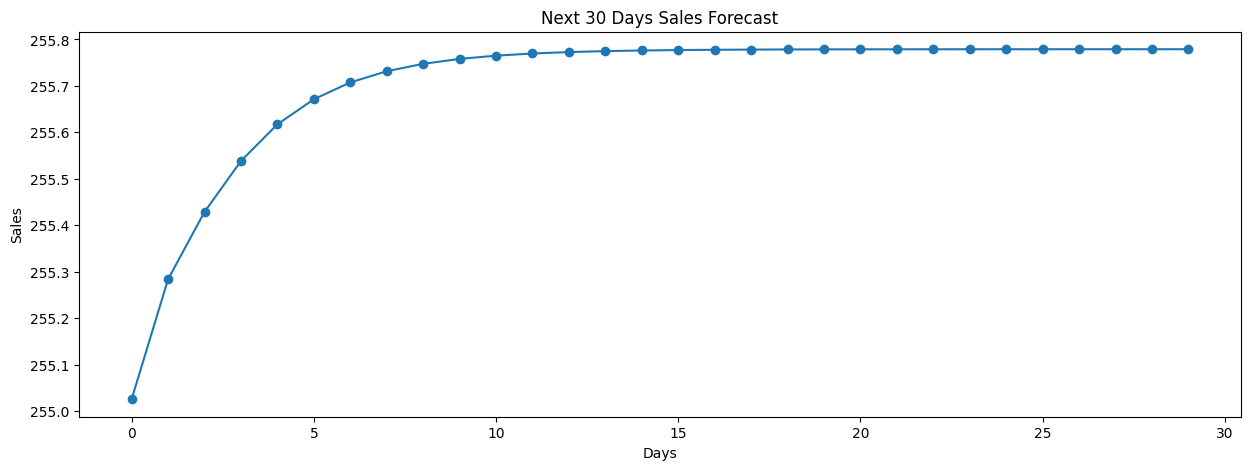

In [20]:
plt.figure(figsize=(15,5))

plt.plot(
    future30,
    marker="o"
)

plt.title("Next 30 Days Sales Forecast")

plt.xlabel("Days")

plt.ylabel("Sales")

plt.show()

In [21]:
forecast_df = pd.DataFrame({

    "Day": range(1,31),

    "ForecastSales": future30.flatten()

})

forecast_df.to_csv(

    "lstm_forecast.csv",

    index=False

)

forecast_df.head()

,Day,ForecastSales
0,1,255.025906
1,2,255.283878
2,3,255.428889
3,4,255.538403
4,5,255.617276
